In [85]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [14]:
import numpy as np

In [15]:
import numpy as np
import sys
import pickle as pkl
import networkx as nx
import scipy.sparse as sp


def parse_index_file(filename):
    index = []
    for line in open(filename):
        index.append(int(line.strip()))
    return index


def load_data(dataset):
    # load the data: x, tx, allx, graph
    names = ['x', 'tx', 'allx', 'graph']
    objects = []
    for i in range(len(names)):
        with open("citeseer/ind.{}.{}".format(dataset, names[i]), 'rb') as f:
            if sys.version_info > (3, 0):
                objects.append(pkl.load(f, encoding='latin1'))
            else:
                objects.append(pkl.load(f))
    x, tx, allx, graph = tuple(objects)
    test_idx_reorder = parse_index_file("citeseer/ind.{}.test.index".format(dataset))
    test_idx_range = np.sort(test_idx_reorder)

    if dataset == 'citeseer':
        # Fix citeseer dataset (there are some isolated nodes in the graph)
        # Find isolated nodes, add them as zero-vecs into the right position
        test_idx_range_full = range(min(test_idx_reorder), max(test_idx_reorder)+1)
        tx_extended = sp.lil_matrix((len(test_idx_range_full), x.shape[1]))
        tx_extended[test_idx_range-min(test_idx_range), :] = tx
        tx = tx_extended

    features = sp.vstack((allx, tx)).tolil()
    features[test_idx_reorder, :] = features[test_idx_range, :]
    adj = nx.adjacency_matrix(nx.from_dict_of_lists(graph))

    return adj, features

In [16]:
adj, features = load_data('citeseer')


/tmp/ipykernel_9983/760385428.py:22: DeprecationWarning: Please import `csr_matrix` from the `scipy.sparse` namespace; the `scipy.sparse.csr` namespace is deprecated and will be removed in SciPy 2.0.0.
  objects.append(pkl.load(f, encoding='latin1'))


In [17]:
adj_list = adj.toarray()
features_list = features.toarray()


In [5]:
adj_list
#adj_list[0]


array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [6]:
print(adj_list[1][158])

1


In [7]:
print(features_list[0])

[0. 0. 0. ... 0. 0. 0.]


In [8]:
def transitive_closure(graph):
    n = len(graph)
    closure = [[0] * n for _ in range(n)]
    
    # Initialize closure with the given graph's edges
    for i in range(n):
        for j in range(n):
            closure[i][j] = graph[i][j]
    
    # Compute transitive closure using Warshall's algorithm
    for k in range(n):
        for i in range(n):
            for j in range(n):
                closure[i][j] = closure[i][j] or (closure[i][k] and closure[k][j])
    
    return closure

# Example graph represented as an adjacency matrix
graph = [
    [1, 1, 0, 1],
    [0, 1, 1, 0],
    [0, 0, 1, 1],
    [0, 0, 0, 1]
]

trans_closure = transitive_closure(graph)
for row in trans_closure:
    print(row)


[1, 1, 1, 1]
[0, 1, 1, 1]
[0, 0, 1, 1]
[0, 0, 0, 1]


In [9]:
from braket.circuits import Circuit
crt = Circuit()
theta = 0.7
unitary_matrix = np.array([[np.cos(theta), -np.sin(theta)],
                           [np.sin(theta), np.cos(theta)]])
       # unitary_gate = UnitaryGate(unitary_matrix)
for i in range(len(adj_list)):
        crt.unitary(matrix = unitary_matrix,targets = [i])
    #result = device.run(crt, shots=1000).result()
#print(crt)

In [ ]:
j=0
for i in range(len(adj_list)):
        if i != j:
           # print(i,j)
            crt.cnot(i,j)
            j +=1
print(crt)

In [21]:
from sklearn.decomposition import PCA
import numpy as np

# Example data: word attributes (replace with your data)
word_attributes = features_list

# Instantiate PCA object
pca = PCA(n_components=2)  # Reduce to 2 dimensions

# Fit and transform the data
word_attributes_reduced = pca.fit_transform(word_attributes)

# print("Original shape:", word_attributes.shape)
# print("Reduced shape:", word_attributes_reduced.shape)
# print("Reduced data:")
# print(word_attributes_reduced)


In [11]:
points_list = []
for i, point in enumerate(points_coordinates):
    points_list.append((point[0], point[1]))

In [30]:
word_attributes_reduced = word_attributes_reduced.tolist()
outliers = [3144,1965,904,237,66]
for i in outliers:
    del word_attributes_reduced[i]


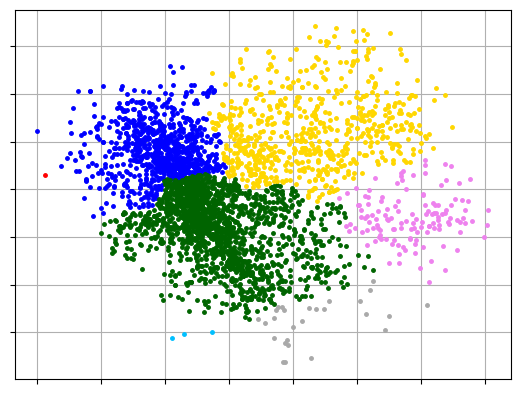

In [32]:
#CURE clustering
from pyclustering.cluster import cluster_visualizer;
from pyclustering.cluster.cure import cure;
from pyclustering.utils import read_sample;
from pyclustering.samples.definitions import FCPS_SAMPLES;
 
# Input data in following format [ [0.1, 0.5], [0.3, 0.1], ... ].
input_data = word_attributes_reduced#read_sample(FCPS_SAMPLES.SAMPLE_LSUN);
 
# Allocate three clusters.
cure_instance = cure(input_data, 7);
cure_instance.process();
clusters = cure_instance.get_clusters();
 
# Visualize allocated clusters.
visualizer = cluster_visualizer();
visualizer.append_clusters(clusters, input_data);
visualizer.show();

In [29]:
clusters[3]

[237, 1965, 66]

In [121]:
#sample the representative points
import random
def node_cluster_sampling(cluster_no, clusters):
    b = []
    a =[]
    a.append(random.sample(clusters[cluster_no], k=3))
    
    for j in range(len(clusters)):
            if cluster_no != j:
                b.append(random.sample(clusters[j], k=1))
                #print(a)
        #new_adj.append(a)        
    return a,b        

In [130]:
node_cluster_sampling(0,clusters)

([[2, 1122, 2628]], [[2779]])

In [132]:
pip install more_itertools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.0/57.0 kB 6.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [135]:
from more_itertools import flatten

# Example nested list
nested_list = node_cluster_sampling(0,clusters)

# Flatten the list
flattened_list = list(flatten(flatten(nested_list)))

print(flattened_list)


[1434, 1412, 941, 1940]


In [136]:
import numpy as np

def subgraph_adjacency_matrix(graph_adj_matrix, subgraph_nodes):
    # Extract the rows and columns corresponding to the subgraph nodes
    subgraph_adj_matrix = graph_adj_matrix[subgraph_nodes][:, subgraph_nodes]
    return subgraph_adj_matrix

# Example graph represented as an adjacency matrix
graph_adj_matrix =adj_list
# Example subgraph with nodes 1, 2, and 3
subgraph_nodes = flattened_list

# Find adjacency matrix of subgraph
subgraph_adj_matrix = subgraph_adjacency_matrix(graph_adj_matrix, subgraph_nodes)

# Print adjacency matrix of subgraph
print("Adjacency Matrix of Subgraph:")
print(subgraph_adj_matrix)


Adjacency Matrix of Subgraph:
[[0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]]


In [77]:
def convert_cluster_list(cluster_list):
    # Create a dictionary to store points belonging to each cluster
    cluster_dict = {}

    # Iterate over each cluster and its points
    for cluster_idx, points in enumerate(cluster_list):
        for point in points:
            # Check if point already exists in any cluster
            if point in cluster_dict:
                # Append current cluster index to the list of clusters for the point
                cluster_dict[point].append(cluster_idx)
            else:
                # Initialize a list for the point and append the current cluster index
                cluster_dict[point] = [cluster_idx]

    # Convert the dictionary to a list where each element is a list of clusters for each point
    points_clusters_list = [cluster_dict[point] for point in range(len(cluster_dict))]

    return points_clusters_list


In [103]:
#Funtction for cluster size determination using DB
from sklearn.metrics import davies_bouldin_score
def cure_score(data,center):
    cure_instance = cure(data, center);
    cure_instance.process();
    clusters = cure_instance.get_clusters();
    model = convert_cluster_list(clusters)
    score = davies_bouldin_score(points_list, model)
    
    return score

/home/ec2-user/anaconda3/envs/Braket/lib/python3.10/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/ec2-user/anaconda3/envs/Braket/lib/python3.10/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/ec2-user/anaconda3/envs/Braket/lib/python3.10/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/ec2-user/anaconda3/envs/Braket/lib/python3.10/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-v

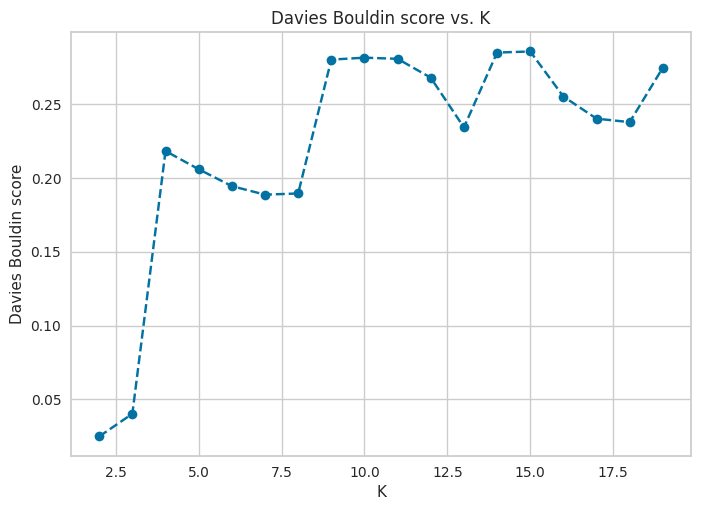

In [107]:
#from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
scores = []
centers = list(range(2,20))
for center in centers:
    scores.append(cure_score(points_list, center))
    
plt.plot(centers, scores, linestyle='--', marker='o', color='b');
plt.xlabel('K');
plt.ylabel('Davies Bouldin score');
plt.title('Davies Bouldin score vs. K');

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

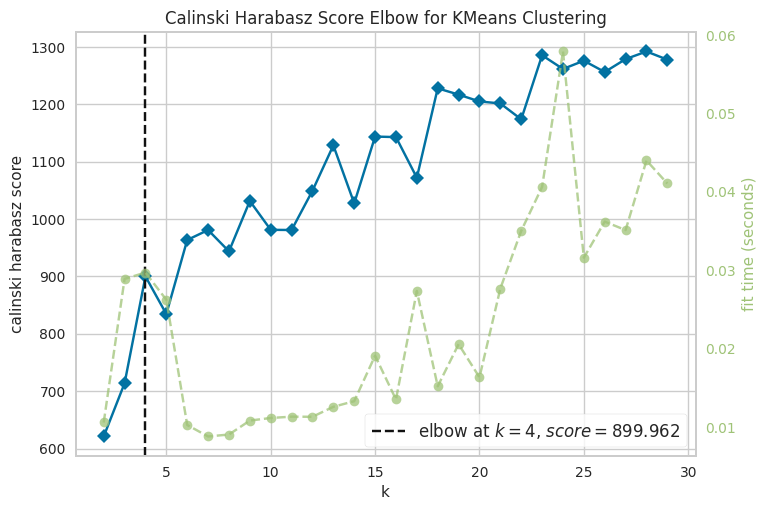

<Axes: title={'center': 'Calinski Harabasz Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='calinski harabasz score'>

In [86]:
from yellowbrick.cluster import KElbowVisualizer
model = KMeans()
# k is range of number of clusters.
visualizer = KElbowVisualizer(model, k=(2,30),metric='calinski_harabasz', timings= True)
visualizer.fit(points_list)        # Fit the data to the visualizer
visualizer.show()  

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

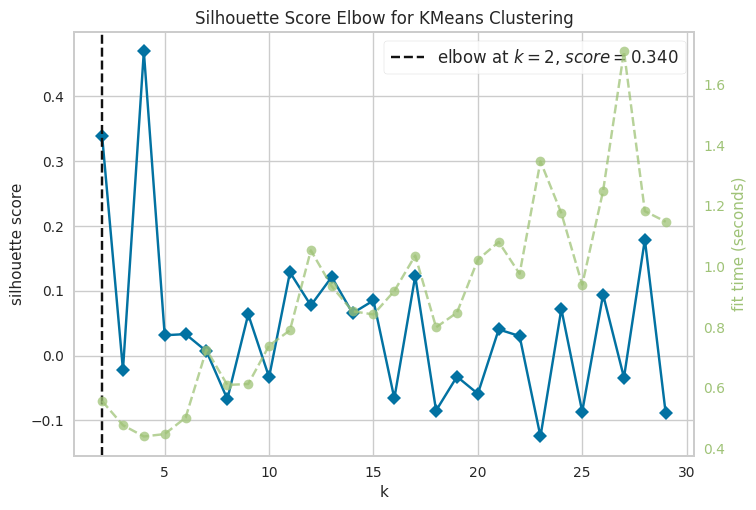

<Axes: title={'center': 'Silhouette Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='silhouette score'>

In [115]:
from yellowbrick.cluster import KElbowVisualizer
model = KMeans()
# k is range of number of clusters.
visualizer = KElbowVisualizer(model, k=(2,30),metric='silhouette', timings= True)
visualizer.fit(adj_list)        # Fit the data to the visualizer
visualizer.show() 

In [92]:
model = convert_cluster_list(clusters)

In [110]:
from sklearn.metrics import silhouette_score
from sklearn.metrics import silhouette_samples
import numpy as np

def calculate_silhouette_coefficient(X, labels):
    """
    Calculate the silhouette coefficient for clustering results.

    Parameters:
        X (array-like): Feature matrix of shape (n_samples, n_features).
        labels (array-like): Predicted cluster labels for each sample.

    Returns:
        silhouette_avg (float): Mean silhouette coefficient for all samples.
        silhouette_values (array-like): Silhouette coefficient for each sample.
    """
    silhouette_avg = silhouette_score(X, labels)
    silhouette_values = silhouette_samples(X, labels)
    return silhouette_avg

# Example usage:
# X is your data, and labels are the predicted cluster labels
# Replace X and labels with your data and predicted labels
#X = np.array([[1, 2], [1, 4], [1, 0], [4, 2], [4, 4], [4, 0]])
# #labels = np.array([0, 0, 1, 1, 2, 2])  # Example labels
# silhouette_avg, silhouette_values = calculate_silhouette_coefficient(points_list, model)
# print("Silhouette Coefficient:", silhouette_avg)
# print("Silhouette Values for each sample:", silhouette_values)


In [ ]:
#Determining sillouette coefficient FOR CURE
def sill_score(data,center):
    cure_instance = cure(data, center);
    cure_instance.process();
    clusters = cure_instance.get_clusters();
    model = convert_cluster_list(clusters)
    score = calculate_silhouette_coefficient(points_list, model)
    
    return score

/home/ec2-user/anaconda3/envs/Braket/lib/python3.10/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/ec2-user/anaconda3/envs/Braket/lib/python3.10/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/ec2-user/anaconda3/envs/Braket/lib/python3.10/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/ec2-user/anaconda3/envs/Braket/lib/python3.10/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-v

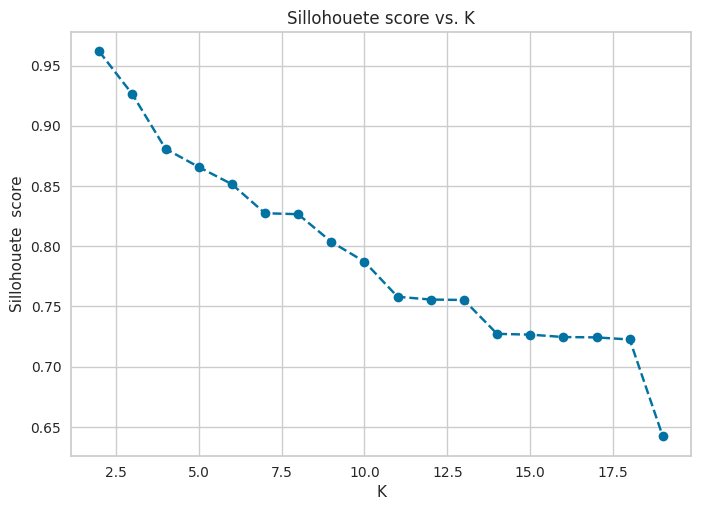

In [116]:
#from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
scores = []
centers = list(range(2,20))
for center in centers:
    scores.append(sill_score(points_list, center))
    
plt.plot(centers, scores, linestyle='--', marker='o', color='b');
plt.xlabel('K');
plt.ylabel('Sillohouete  score');
plt.title('Sillohouete score vs. K');